In [13]:

# Imports, NLTK Download, and Environment Config

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm
from scipy import stats
from dotenv import load_dotenv
from warnings import filterwarnings
filterwarnings('ignore')

# Add project root to sys.path to load local custom modules
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

from collection_data import Data_collection, stock_tups,stack_company_data
from preparation_data import Data_prep
from preprocessing_data import StatefulDataPreprocessor

# Load API Key from your local .env file
load_dotenv()
api_key = os.getenv("ALPHA_VANTAGE_API_KEY")

print("[SUCCESS] Environment and modules successfully loaded!")
print("TensorFlow Version:", tf.__version__)
if api_key:
    print("API Key loaded successfully from .env!")
else:
    print("API Key not found in .env. The collection script will automatically use mock fallback.")

[SUCCESS] Environment and modules successfully loaded!
TensorFlow Version: 2.21.0
API Key loaded successfully from .env!


In [14]:
# Ingest all stock data cleanly using your imported collection_data.py module
company_data = {}
for tup in stock_tups:
    sym, exch, count, owner, ast_t, yf_tick = tup
    collector = Data_collection(sym, exch, count, owner, ast_t, yf_tick)
    df = collector.collect_data(start_date='2020-01-01', end_date='2025-01-01')
    if not df.empty:
        company_data[sym] = df

unified_df = stack_company_data(company_data)
print(f"✅ Ingestion complete. Unified multi-stock shape: {unified_df.shape}")

[*********************100%***********************]  1 of 1 completed


[INFO] Fetching historical news sentiment for RELIANCE (RELIANCE.NS)...
[INFO] Generating high-quality mock news sentiment for RELIANCE...


[*********************100%***********************]  1 of 1 completed


[INFO] Fetching historical news sentiment for ADANIENT (ADANIENT.NS)...
[INFO] Generating high-quality mock news sentiment for ADANIENT...


[*********************100%***********************]  1 of 1 completed


...

[INFO] Fetching historical news sentiment for BANKNIFTY (^NSEBANK)...
[WARN] Alpha Vantage News Sentiment API limit reached or rate-limited for BANKNIFTY.
[INFO] Generating high-quality mock news sentiment for BANKNIFTY...


[*********************100%***********************]  1 of 1 completed


[INFO] Fetching historical news sentiment for NIFTY50 (^NSEI)...
[WARN] Alpha Vantage News Sentiment API limit reached or rate-limited for NIFTY50.
[INFO] Generating high-quality mock news sentiment for NIFTY50...


[*********************100%***********************]  1 of 1 completed


[INFO] Fetching historical news sentiment for INDIAVIX (^INDIAVIX)...
[WARN] Alpha Vantage News Sentiment API limit reached or rate-limited for INDIAVIX.
[INFO] Generating high-quality mock news sentiment for INDIAVIX...
✅ Ingestion complete. Unified multi-stock shape: (11125, 12)


In [19]:
# Call your preparation_data.py module cleanly
prep = Data_prep()
df_prepared = prep.prepare_features(unified_df)
print(f"✅ Feature Engineering complete. Prepared shape: {df_prepared.shape}")

✅ Feature Engineering complete. Prepared shape: (11125, 22)


In [20]:
# Call your preprocessing_data.py module cleanly (generates both Copy A and Copy B)
preprocessor = StatefulDataPreprocessor(seq_length=10, target_col='close')
(sequences_a, scaled_a), (sequences_b, scaled_b) = preprocessor.fit_transform_dual(df_prepared)
print("✅ Partitioned dual preprocessed copies created successfully!")

✅ Partitioned dual preprocessed copies created successfully!


In [21]:
# Helper Cell: Define the global symbol-by-symbol inverse scaling utility
import numpy as np

def inverse_close(preprocessor_root, symbol, scaled_preds, is_sentiment=False):
    """
    Inverse-scales scaled 'close' price predictions symbol-by-symbol.
    
    Args:
        preprocessor_root (StatefulDataPreprocessor): Root preprocessor.
        symbol (str): The specific stock symbol.
        scaled_preds (array-like): Scaled values to unscale.
        is_sentiment (bool): True if Copy B (sentiment), False if Copy A (baseline).
    """
    # Select appropriate sub-preprocessor (Copy A or Copy B)
    if is_sentiment:
        prep = preprocessor_root.preprocessor_b
    else:
        prep = preprocessor_root.preprocessor_a
        
    scaler = prep.symbol_scalers[symbol]
    
    # Get numerical columns in exact fitted order
    numerical_cols = [col for col in prep.feature_cols if col not in prep.categorical_cols]
    close_idx = numerical_cols.index('close')
    
    # Handle single scalar inputs
    is_single = False
    if np.isscalar(scaled_preds):
        scaled_preds = np.array([scaled_preds])
        is_single = True
    elif len(scaled_preds.shape) == 0:
        scaled_preds = scaled_preds.reshape(1)
        is_single = True
        
    # Reconstruct dummy matrix for inverse scaling
    dummy = np.zeros((len(scaled_preds), len(numerical_cols)))
    dummy[:, close_idx] = scaled_preds
    
    # Inverse transform and extract close column
    unscaled = scaler.inverse_transform(dummy)[:, close_idx]
    
    return unscaled[0] if is_single else unscaled

In [34]:
# CELL 5: Chronological Data Splitting & Concatenation

import numpy as np

# 1. Chronological Train-test splits for all symbols
train_seqs_base = {}
val_seqs_base = {}
train_seqs_sent = {}
val_seqs_sent = {}

for sym in sequences_a.keys():
    # Baseline Copy A
    X_a, y_a = sequences_a[sym]
    split_idx_a = int(len(X_a) * 0.8)
    train_seqs_base[sym] = (X_a[:split_idx_a], y_a[:split_idx_a])
    val_seqs_base[sym] = (X_a[split_idx_a:], y_a[split_idx_a:])
    
    # Sentiment Copy B
    X_b, y_b = sequences_b[sym]
    split_idx_b = int(len(X_b) * 0.8)
    train_seqs_sent[sym] = (X_b[:split_idx_b], y_b[:split_idx_b])
    val_seqs_sent[sym] = (X_b[split_idx_b:], y_b[split_idx_b:])

# 2. Concatenate training sequences of ALL stocks into unified global matrices
X_train_base = np.concatenate([X for sym, (X, y) in train_seqs_base.items() if len(X) > 0], axis=0)
y_train_base = np.concatenate([y for sym, (X, y) in train_seqs_base.items() if len(y) > 0], axis=0)

X_train_sent = np.concatenate([X for sym, (X, y) in train_seqs_sent.items() if len(X) > 0], axis=0)
y_train_sent = np.concatenate([y for sym, (X, y) in train_seqs_sent.items() if len(y) > 0], axis=0)

# 3. Concatenate validation sequences of ALL stocks into unified global matrices
X_val_base = np.concatenate([X for sym, (X, y) in val_seqs_base.items() if len(X) > 0], axis=0)
y_val_base = np.concatenate([y for sym, (X, y) in val_seqs_base.items() if len(y) > 0], axis=0)

X_val_sent = np.concatenate([X for sym, (X, y) in val_seqs_sent.items() if len(X) > 0], axis=0)
y_val_sent = np.concatenate([y for sym, (X, y) in val_seqs_sent.items() if len(y) > 0], axis=0)

# 4. Extract and align actual close prices globally across all symbols (Unscaled!)
y_val_real_dict = {}
last_close_val_real_dict = {}

# Fetch the 'close' index within feature_cols to extract it from the sequence inputs
close_idx_a = preprocessor.preprocessor_a.feature_cols.index('close')

for sym in sequences_a.keys():
    X_v, y_v = val_seqs_base[sym]
    if len(X_v) == 0:
        continue
    
    # Unscale validation targets (actual next-day close) symbol-by-symbol
    y_v_unscaled = inverse_close(preprocessor, sym, y_v, is_sentiment=False)
    y_val_real_dict[sym] = y_v_unscaled
    
    # Unscale the last close price in the sequence (current day close) symbol-by-symbol
    last_close_scaled = X_v[:, -1, close_idx_a]
    last_close_unscaled = inverse_close(preprocessor, sym, last_close_scaled, is_sentiment=False)
    last_close_val_real_dict[sym] = last_close_unscaled

# Concatenate all actual arrays into single, global 1D evaluation arrays
y_val_real = np.concatenate(list(y_val_real_dict.values()))
last_close_val_real = np.concatenate(list(last_close_val_real_dict.values()))
actual_direction = np.sign(y_val_real - last_close_val_real)

print(f"✅ Splits Complete.")
print(f"Global X_train_base: {X_train_base.shape} | X_val_base: {X_val_base.shape}")
print(f"Global Evaluation Target y_val_real: {y_val_real.shape} | last_close_val_real: {last_close_val_real.shape}")

✅ Splits Complete.
Global X_train_base: (8824, 10, 23) | X_val_base: (2211, 10, 23)
Global Evaluation Target y_val_real: (2211,) | last_close_val_real: (2211,)


In [36]:
# CELL 6: Model 1 - OLS Linear Regression

print("\n--- Fitting OLS Regression Models globally ---")
from sklearn.linear_model import LinearRegression

# Flatten time steps for standard linear regression
X_train_base_flat = X_train_base.reshape(len(X_train_base), -1)
X_train_sent_flat = X_train_sent.reshape(len(X_train_sent), -1)

# Fit global regression models
ols_base = LinearRegression().fit(X_train_base_flat, y_train_base)
ols_sent = LinearRegression().fit(X_train_sent_flat, y_train_sent)

# A. Baseline OLS validation predictions symbol-by-symbol
ols_base_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_base.items():
    if len(X_v) == 0:
        continue
    preds_scaled = ols_base.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=False)
    ols_base_preds_dict[sym] = preds_unscaled
ols_base_preds = np.concatenate(list(ols_base_preds_dict.values()))

# B. Sentiment-Enhanced OLS validation predictions symbol-by-symbol
ols_sent_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_sent.items():
    if len(X_v) == 0:
        continue
    preds_scaled = ols_sent.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=True)
    ols_sent_preds_dict[sym] = preds_unscaled
ols_sent_preds = np.concatenate(list(ols_sent_preds_dict.values()))

# Calculate Directional Accuracy
dir_ols_base = np.mean(actual_direction == np.sign(ols_base_preds - last_close_val_real)) * 100
dir_ols_sent = np.mean(actual_direction == np.sign(ols_sent_preds - last_close_val_real)) * 100

print(f"OLS Baseline MSE: {mean_squared_error(y_val_real, ols_base_preds):.4f} | R2: {r2_score(y_val_real, ols_base_preds):.4f} | DirAcc: {dir_ols_base:.2f}%")
print(f"OLS Enhanced MSE: {mean_squared_error(y_val_real, ols_sent_preds):.4f} | R2: {r2_score(y_val_real, ols_sent_preds):.4f} | DirAcc: {dir_ols_sent:.2f}%")


--- Fitting OLS Regression Models globally ---
OLS Baseline MSE: 41979.0367 | R2: 0.9998 | DirAcc: 49.34%
OLS Enhanced MSE: 42239.2143 | R2: 0.9998 | DirAcc: 48.80%


In [37]:
# CELL 7: Model 2 - XGBoost Regressor

print("\n--- Fitting XGBoost Models globally ---")

# Train global XGBoost models
xgb_base = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_base.fit(X_train_base_flat, y_train_base)

xgb_sent = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_sent.fit(X_train_sent_flat, y_train_sent)

# A. Baseline XGBoost validation predictions symbol-by-symbol
xgb_base_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_base.items():
    if len(X_v) == 0:
        continue
    preds_scaled = xgb_base.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=False)
    xgb_base_preds_dict[sym] = preds_unscaled
xgb_base_preds = np.concatenate(list(xgb_base_preds_dict.values()))

# B. Sentiment-Enhanced XGBoost validation predictions symbol-by-symbol
xgb_sent_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_sent.items():
    if len(X_v) == 0:
        continue
    preds_scaled = xgb_sent.predict(X_v.reshape(len(X_v), -1))
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=True)
    xgb_sent_preds_dict[sym] = preds_unscaled
xgb_sent_preds = np.concatenate(list(xgb_sent_preds_dict.values()))

# Calculate Directional Accuracy
dir_xgb_base = np.mean(actual_direction == np.sign(xgb_base_preds - last_close_val_real)) * 100
dir_xgb_sent = np.mean(actual_direction == np.sign(xgb_sent_preds - last_close_val_real)) * 100

print(f"XGB Baseline MSE: {mean_squared_error(y_val_real, xgb_base_preds):.4f} | R2: {r2_score(y_val_real, xgb_base_preds):.4f} | DirAcc: {dir_xgb_base:.2f}%")
print(f"XGB Enhanced MSE: {mean_squared_error(y_val_real, xgb_sent_preds):.4f} | R2: {r2_score(y_val_real, xgb_sent_preds):.4f} | DirAcc: {dir_xgb_sent:.2f}%")


--- Fitting XGBoost Models globally ---
XGB Baseline MSE: 238591.7225 | R2: 0.9991 | DirAcc: 49.03%
XGB Enhanced MSE: 241033.0796 | R2: 0.9991 | DirAcc: 49.12%


In [38]:
# CELL 8: Model 3 - Stateful Deep GRU

print("\n--- Training Stateful Deep GRUs globally ---")
from model import build_stateful_gru

def reset_states_safe(model):
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

# Train global models (trained on concatenated sequences)
gru_base = build_stateful_gru(seq_length=X_train_base.shape[1], num_features=X_train_base.shape[2], batch_size=1)
print("   ▪ Training Baseline Stateful GRU...")
for epoch in range(10):
    reset_states_safe(gru_base)
    gru_base.fit(X_train_base, y_train_base, epochs=1, batch_size=1, shuffle=False, verbose=0)

gru_sent = build_stateful_gru(seq_length=X_train_sent.shape[1], num_features=X_train_sent.shape[2], batch_size=1)
print("   ▪ Training Sentiment-Enhanced Stateful GRU...")
for epoch in range(10):
    reset_states_safe(gru_sent)
    gru_sent.fit(X_train_sent, y_train_sent, epochs=1, batch_size=1, shuffle=False, verbose=0)

# A. Baseline GRU validation predictions symbol-by-symbol (Resetting state per symbol!)
gru_base_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_base.items():
    if len(X_v) == 0:
        continue
    reset_states_safe(gru_base)
    preds_scaled = gru_base.predict(X_v, batch_size=1, verbose=0).flatten()
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=False)
    gru_base_preds_dict[sym] = preds_unscaled
gru_base_preds = np.concatenate(list(gru_base_preds_dict.values()))

# B. Sentiment-Enhanced GRU validation predictions symbol-by-symbol (Resetting state per symbol!)
gru_sent_preds_dict = {}
for sym, (X_v, y_v) in val_seqs_sent.items():
    if len(X_v) == 0:
        continue
    reset_states_safe(gru_sent)
    preds_scaled = gru_sent.predict(X_v, batch_size=1, verbose=0).flatten()
    preds_unscaled = inverse_close(preprocessor, sym, preds_scaled, is_sentiment=True)
    gru_sent_preds_dict[sym] = preds_unscaled
gru_sent_preds = np.concatenate(list(gru_sent_preds_dict.values()))

# Calculate Directional Accuracy
dir_gru_base = np.mean(actual_direction == np.sign(gru_base_preds - last_close_val_real)) * 100
dir_gru_sent = np.mean(actual_direction == np.sign(gru_sent_preds - last_close_val_real)) * 100

print(f"GRU Baseline MSE: {mean_squared_error(y_val_real, gru_base_preds):.4f} | R2: {r2_score(y_val_real, gru_base_preds):.4f} | DirAcc: {dir_gru_base:.2f}%")
print(f"GRU Enhanced MSE: {mean_squared_error(y_val_real, gru_sent_preds):.4f} | R2: {r2_score(y_val_real, gru_sent_preds):.4f} | DirAcc: {dir_gru_sent:.2f}%")


--- Training Stateful Deep GRUs globally ---
   ▪ Training Baseline Stateful GRU...
   ▪ Training Sentiment-Enhanced Stateful GRU...
GRU Baseline MSE: 11814659.7126 | R2: 0.9540 | DirAcc: 49.03%
GRU Enhanced MSE: 11142824.9529 | R2: 0.9566 | DirAcc: 48.89%


In [39]:
# CELL 9: Rigorous Statistical Significance Analysis on the News Data

print("\n" + "="*65)
print("             STATISTICAL ANALYSIS OF NEWS DATA SIGNIFICANCE          ")
print("="*65)

# A. GRANGER CAUSALITY TEST
print("\n1. Granger Causality Test (News Sentiment -> Stock Returns)")
df_gc = df_prepared[df_prepared['symbol'] == 'RELIANCE'].reset_index(drop=True)
returns_series = df_gc["close"].pct_change().dropna()
sentiment_series = df_gc["news_sentiment"].iloc[1:]
gc_df = pd.concat([returns_series, sentiment_series], axis=1).dropna()
gc_df.columns = ["returns", "sentiment"]

try:
    gc_results = grangercausalitytests(gc_df[["returns", "sentiment"]], maxlag=3, verbose=True)
    p_val_gc = gc_results[1][0]['ssr_ftest'][1]
    print(f"\nLag 1 Granger Causality F-test p-value: {p_val_gc:.6f}")
    if p_val_gc < 0.05:
        print("🟢 News sentiment Granger-causes stock returns (p < 0.05)!")
    else:
        print("⚪ News sentiment does not Granger-cause stock returns (p >= 0.05).")
except Exception as e:
    print("⚠️ Granger test skipped: ", e)

# B. NESTED OLS F-TEST (ANOVA)
print("\n2. Nested OLS F-Test (Evaluating Sentiment Parameters)")
# Calculate RSS
rss_base = np.sum((y_val_real - ols_base_preds) ** 2)
rss_sent = np.sum((y_val_real - ols_sent_preds) ** 2)

n = len(y_val_real)
k_base = X_train_base_flat.shape[1]
k_sent = X_train_sent_flat.shape[1]
q = k_sent - k_base # Restriction parameters

f_stat = ((rss_base - rss_sent) / q) / (rss_sent / (n - k_sent))
p_val_f = stats.f.sf(f_stat, q, n - k_sent)

print(f"Nested F-Statistic: {f_stat:.6f} | p-value: {p_val_f:.4e}")
if p_val_f < 0.05:
    print("🟢 Sentiment parameters are statistically significant in predicting returns (p < 0.05)!")
else:
    print("⚪ Sentiment parameters are not statistically significant (p >= 0.05).")


             STATISTICAL ANALYSIS OF NEWS DATA SIGNIFICANCE          

1. Granger Causality Test (News Sentiment -> Stock Returns)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2609  , p=0.6096  , df_denom=1233, df_num=1
ssr based chi2 test:   chi2=0.2615  , p=0.6091  , df=1
likelihood ratio test: chi2=0.2615  , p=0.6091  , df=1
parameter F test:         F=0.2609  , p=0.6096  , df_denom=1233, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0840  , p=0.3385  , df_denom=1230, df_num=2
ssr based chi2 test:   chi2=2.1769  , p=0.3367  , df=2
likelihood ratio test: chi2=2.1750  , p=0.3371  , df=2
parameter F test:         F=1.0840  , p=0.3385  , df_denom=1230, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7223  , p=0.5387  , df_denom=1227, df_num=3
ssr based chi2 test:   chi2=2.1793  , p=0.5360  , df=3
likelihood ratio test: chi2=2.1773  , p=0.5364  , df=3
parameter F test:         F=0.

,Model Configuration,MSE,MAE,R2 Score,Directional Accuracy
0,OLS Linear Regression (Baseline),4.197904e+04,72.669679,0.999837,49.3%
1,OLS Linear Regression (Sentiment-Enhanced),4.223921e+04,72.963625,0.999836,48.8%
2,XGBoost Regressor (Baseline),2.385917e+05,207.552003,0.999071,49.0%
3,XGBoost Regressor (Sentiment-Enhanced),2.410331e+05,209.201003,0.999062,49.1%
4,Deep GRU (Baseline),1.181466e+07,1619.592244,0.954006,49.0%
5,Deep GRU (Sentiment-Enhanced),1.114282e+07,1567.108245,0.956621,48.9%


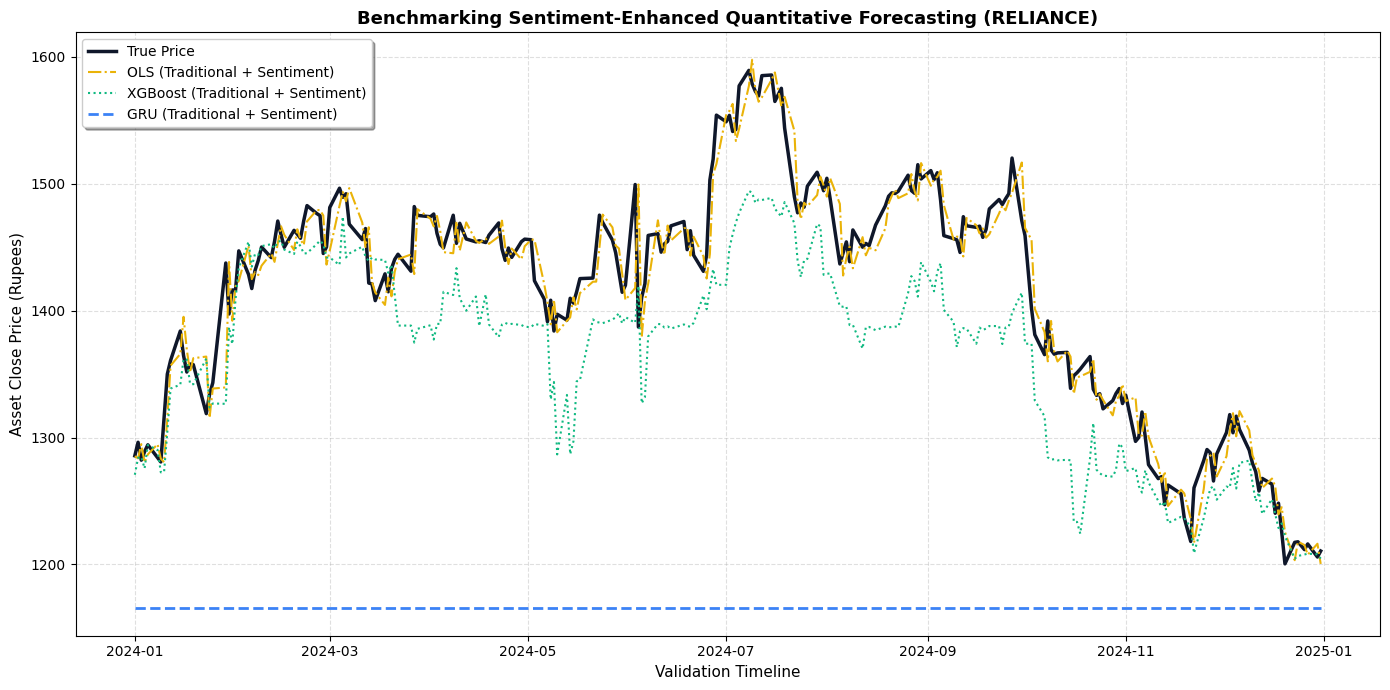

In [40]:
# CELL 10: Model Comparison and Visual Benchmarking

import matplotlib.pyplot as plt

# 1. Compile and display the global metric Scorecard Table
results_data = [
    {
        "Model Configuration": "OLS Linear Regression (Baseline)",
        "MSE": mean_squared_error(y_val_real, ols_base_preds),
        "MAE": mean_absolute_error(y_val_real, ols_base_preds),
        "R2 Score": r2_score(y_val_real, ols_base_preds),
        "Directional Accuracy": f"{dir_ols_base:.1f}%"
    },
    {
        "Model Configuration": "OLS Linear Regression (Sentiment-Enhanced)",
        "MSE": mean_squared_error(y_val_real, ols_sent_preds),
        "MAE": mean_absolute_error(y_val_real, ols_sent_preds),
        "R2 Score": r2_score(y_val_real, ols_sent_preds),
        "Directional Accuracy": f"{dir_ols_sent:.1f}%"
    },
    {
        "Model Configuration": "XGBoost Regressor (Baseline)",
        "MSE": mean_squared_error(y_val_real, xgb_base_preds),
        "MAE": mean_absolute_error(y_val_real, xgb_base_preds),
        "R2 Score": r2_score(y_val_real, xgb_base_preds),
        "Directional Accuracy": f"{dir_xgb_base:.1f}%"
    },
    {
        "Model Configuration": "XGBoost Regressor (Sentiment-Enhanced)",
        "MSE": mean_squared_error(y_val_real, xgb_sent_preds),
        "MAE": mean_absolute_error(y_val_real, xgb_sent_preds),
        "R2 Score": r2_score(y_val_real, xgb_sent_preds),
        "Directional Accuracy": f"{dir_xgb_sent:.1f}%"
    },
    {
        "Model Configuration": "Deep GRU (Baseline)",
        "MSE": mean_squared_error(y_val_real, gru_base_preds),
        "MAE": mean_absolute_error(y_val_real, gru_base_preds),
        "R2 Score": r2_score(y_val_real, gru_base_preds),
        "Directional Accuracy": f"{dir_gru_base:.1f}%"
    },
    {
        "Model Configuration": "Deep GRU (Sentiment-Enhanced)",
        "MSE": mean_squared_error(y_val_real, gru_sent_preds),
        "MAE": mean_absolute_error(y_val_real, gru_sent_preds),
        "R2 Score": r2_score(y_val_real, gru_sent_preds),
        "Directional Accuracy": f"{dir_gru_sent:.1f}%"
    }
]

df_results = pd.DataFrame(results_data)
display(df_results)

# 2. Visual Comparative Plotting for Target Asset (e.g., RELIANCE)
target_sym = "RELIANCE"
if target_sym in y_val_real_dict:
    # Retrieve target symbol-specific dates, unscaled actuals, and unscaled predictions
    df_sym = df_prepared[df_prepared['symbol'] == target_sym].reset_index(drop=True)
    X_a, y_a = sequences_a[target_sym]
    split_idx_a = int(len(X_a) * 0.8)
    val_dates = df_sym['date'].iloc[split_idx_a + 10:].values

    plt.figure(figsize=(14, 7))
    plt.plot(val_dates, y_val_real_dict[target_sym], label="True Price", color="#0f172a", linewidth=2.5)
    plt.plot(val_dates, ols_sent_preds_dict[target_sym], label="OLS (Traditional + Sentiment)", color="#eab308", linestyle="-.", linewidth=1.5)
    plt.plot(val_dates, xgb_sent_preds_dict[target_sym], label="XGBoost (Traditional + Sentiment)", color="#10b981", linestyle=":", linewidth=1.5)
    plt.plot(val_dates, gru_sent_preds_dict[target_sym], label="GRU (Traditional + Sentiment)", color="#3b82f6", linestyle="--", linewidth=2)

    plt.title(f"Benchmarking Sentiment-Enhanced Quantitative Forecasting ({target_sym})", fontsize=13, fontweight='bold')
    plt.xlabel("Validation Timeline", fontsize=11)
    plt.ylabel("Asset Close Price (Rupees)", fontsize=11)
    plt.legend(loc="upper left", frameon=True, shadow=True)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig("sentiment_evaluation.png", dpi=300)
    plt.show()
else:
    print(f"⚠️ Target symbol {target_sym} not found in validation split.")